<a href="https://colab.research.google.com/github/trunghieumarketer/MIS-301/blob/main/H%C3%A1o_Bi%E1%BB%83u.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS

In [3]:
df_videos = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/videos-stats.csv')
df_comments = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/FINAL PROJECT/comments.csv')

#Overview of the data
Use relevant code to explore and have initial understanding about the dataset (head, info, describe, ...)

##Check the "df_video" first

In [ ]:
df_videos.head()

,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views
0,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0
1,1.0,The most EXPENSIVE thing I own.,b3x28s61q3c,08/24/2022,tech,76779.0,4306.0,1758063.0
2,2.0,My New House Gaming Setup is SICK!,4mgePWWCAmA,08/23/2022,tech,63825.0,3338.0,1564007.0
3,3.0,Petrol Vs Liquid Nitrogen | Freezing Experimen...,kXiYSI7H2b0,08/23/2022,tech,71566.0,1426.0,922918.0
4,4.0,Best Back to School Tech 2022!,ErMwWXQxHp0,8/08/2022,tech,96513.0,5155.0,1855644.0


In [ ]:
df_videos.tail()

,Unnamed: 0,Title,Video ID,Published At,Keyword,Likes,Comments,Views
1876,1876.0,Should You Learn Machine Learning?,AO6urf07KjE,06/14/2021,machine learning,10259.0,416.0,386360.0
1877,1877.0,Todos podemos aprender Machine learning,7ClLKBUvmRk,10/08/2017,machine learning,2981.0,72.0,431421.0
1878,1878.0,"Andrew Ng: Deep Learning, Education, and Real-...",0jspaMLxBig,02/20/2020,machine learning,5198.0,443.0,226152.0
1879,1879.0,What is Machine Learning?,f_uwKZIAeM0,1/11/2017,machine learning,NaN,NaN,NaN
1880,1880.0,Don&#39;t learn machine learning,cyLWtMSry58,03/30/2020,machine learning,NaN,NaN,NaN


In [ ]:
df_videos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1881 entries, 0 to 1880
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1867 non-null   float64
 1   Title         1863 non-null   object 
 2   Video ID      1860 non-null   object 
 3   Published At  1838 non-null   object 
 4   Keyword       1837 non-null   object 
 5   Likes         1836 non-null   float64
 6   Comments      1841 non-null   float64
 7   Views         1847 non-null   float64
dtypes: float64(4), object(4)
memory usage: 117.7+ KB


In [ ]:
df_videos.describe()

,Unnamed: 0,Likes,Comments,Views
count,1867.000000,1.836000e+03,1841.000000,1.847000e+03
mean,942.229780,1.718344e+05,7927.416078,1.174573e+07
std,541.569989,8.047348e+05,38245.578385,1.093706e+08
min,0.000000,-1.000000e+00,-1.000000,2.500000e+01
25%,475.500000,2.670750e+03,198.000000,8.358000e+04
50%,942.000000,1.476400e+04,807.000000,5.899070e+05
75%,1408.500000,6.086350e+04,3373.000000,2.804978e+06
max,1880.000000,1.644556e+07,732818.000000,4.034122e+09


##Check the "df_comments" second


> Thêm khối trích dẫn



In [ ]:
df_comments.head()

,Unnamed: 0,Video ID,Comment,Likes,Sentiment
0,0.0,wAZZ-UWGVHI,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,1.0,wAZZ-UWGVHI,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,2.0,wAZZ-UWGVHI,I will forever acknowledge this channel with t...,161.0,2.0
3,3.0,wAZZ-UWGVHI,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,4.0,wAZZ-UWGVHI,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


In [ ]:
df_comments.tail()

,Unnamed: 0,Video ID,Comment,Likes,Sentiment
18402,NaN,NaN,NaN,NaN,NaN
18403,NaN,NaN,NaN,NaN,NaN
18404,NaN,NaN,NaN,NaN,NaN
18405,NaN,NaN,NaN,NaN,NaN
18406,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_comments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18407 entries, 0 to 18406
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7073 non-null   float64
 1   Video ID    7069 non-null   object 
 2   Comment     7058 non-null   object 
 3   Likes       7058 non-null   float64
 4   Sentiment   7063 non-null   float64
dtypes: float64(3), object(2)
memory usage: 719.2+ KB


In [ ]:
df_comments.describe()

,Unnamed: 0,Likes,Sentiment
count,7073.000000,7058.000000,7063.000000
mean,3538.928884,669.747521,1.430412
std,2042.061211,3440.737518,0.741949
min,0.000000,0.000000,0.000000
25%,1771.000000,4.000000,1.000000
50%,3539.000000,26.000000,2.000000
75%,5307.000000,176.000000,2.000000
max,7075.000000,101501.000000,2.000000


#check for the Missing value

##check for the missing value in df_videos first

In [ ]:
df_videos.isna().sum()

,0
Unnamed: 0,14
Title,18
Video ID,21
Published At,43
Keyword,44
Likes,45
Comments,40
Views,34


In [ ]:
for i in df_videos.columns:
    null_rate = df_videos[i].isna().sum() / len(df_videos) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

Unnamed: 0 null rate: 0.74%
Title null rate: 0.96%
Video ID null rate: 1.12%
Published At null rate: 2.29%
Keyword null rate: 2.34%
Likes null rate: 2.39%
Comments null rate: 2.13%
Views null rate: 1.81%


##check for the missing value in df_comments second

In [ ]:
df_comments.isna().sum()

,0
Unnamed: 0,11334
Video ID,11338
Comment,11349
Likes,11349
Sentiment,11344


In [ ]:
for i in df_comments.columns:
    null_rate = df_comments[i].isna().sum() / len(df_comments) * 100
    if null_rate > 0 :
        print("{} null rate: {}%".format(i,round(null_rate,2)))

Unnamed: 0 null rate: 61.57%
Video ID null rate: 61.6%
Comment null rate: 61.66%
Likes null rate: 61.66%
Sentiment null rate: 61.63%


#Dealing with the missing data


In [ ]:
# Drop Na]

df_videos.dropna(inplace=True)
df_comments.dropna(inplace=True)

# Drop Duplicates
df_videos.drop_duplicates(inplace= True)
df_comments.drop_duplicates(inplace= True)

## Check again to see if there are still nulls

In [ ]:
df_videos.isna().sum()

,0
Unnamed: 0,0
Title,0
Video ID,0
Published At,0
Keyword,0
Likes,0
Comments,0
Views,0


In [ ]:
df_comments.isna().sum()

,0
Unnamed: 0,0
Video ID,0
Comment,0
Likes,0
Sentiment,0


##check the hole data agian


In [ ]:
df_videos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1831 entries, 0 to 1878
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    1831 non-null   float64
 1   Title         1831 non-null   object 
 2   Video ID      1831 non-null   object 
 3   Published At  1831 non-null   object 
 4   Keyword       1831 non-null   object 
 5   Likes         1831 non-null   float64
 6   Comments      1831 non-null   float64
 7   Views         1831 non-null   float64
dtypes: float64(4), object(4)
memory usage: 128.7+ KB


In [ ]:
df_comments.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7058 entries, 0 to 7075
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  7058 non-null   float64
 1   Video ID    7058 non-null   object 
 2   Comment     7058 non-null   object 
 3   Likes       7058 non-null   float64
 4   Sentiment   7058 non-null   float64
dtypes: float64(3), object(2)
memory usage: 330.8+ KB


# Merging 2 data set


In [ ]:
df_full = pd.merge(df_videos, df_comments, on='Video ID', how='inner')
display(df_full.head())

,Unnamed: 0_x,Title,Video ID,Published At,Keyword,Likes_x,Comments,Views,Unnamed: 0_y,Comment,Likes_y,Sentiment
0,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,0.0,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,1.0,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,2.0,I will forever acknowledge this channel with t...,161.0,2.0
3,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,3.0,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,0.0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,4.0,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


##check the df_full (full data set after merging)

In [ ]:
df_full.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10719 entries, 0 to 10718
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0_x  10719 non-null  float64
 1   Title         10719 non-null  object 
 2   Video ID      10719 non-null  object 
 3   Published At  10719 non-null  object 
 4   Keyword       10719 non-null  object 
 5   Likes_x       10719 non-null  float64
 6   Comments      10719 non-null  float64
 7   Views         10719 non-null  float64
 8   Unnamed: 0_y  10719 non-null  float64
 9   Comment       10719 non-null  object 
 10  Likes_y       10719 non-null  float64
 11  Sentiment     10719 non-null  float64
dtypes: float64(7), object(5)
memory usage: 1005.0+ KB


In [ ]:
df_full.describe()

,Unnamed: 0_x,Likes_x,Comments,Views,Unnamed: 0_y,Likes_y,Sentiment
count,10719.000000,1.071900e+04,10719.000000,1.071900e+04,10719.000000,10719.000000,10719.000000
mean,526.488945,1.179548e+05,5541.215785,1.133203e+07,3318.165874,542.609945,1.412538
std,430.566591,5.973428e+05,31117.995305,1.262682e+08,2214.944599,2875.871569,0.750428
min,0.000000,-1.000000e+00,1.000000,6.010000e+02,0.000000,0.000000,0.000000
25%,180.000000,1.769000e+03,187.000000,9.276000e+04,1147.000000,3.000000,1.000000
50%,469.000000,1.480000e+04,826.000000,6.210930e+05,3294.000000,18.000000,2.000000
75%,667.000000,7.741100e+04,3338.000000,2.954979e+06,5413.500000,116.000000,2.000000
max,1791.000000,1.644556e+07,732818.000000,4.034122e+09,7075.000000,101501.000000,2.000000


In [ ]:
df_full.isna().sum()

,0
Unnamed: 0_x,0
Title,0
Video ID,0
Published At,0
Keyword,0
Likes_x,0
Comments,0
Views,0
Unnamed: 0_y,0
Comment,0


## Dealing with newdataset


In [ ]:
# Rename columns for clarity
df_full = df_full.rename(columns={
    'Likes_x': 'Video_Likes',
    'Comments': 'Video_Comments',
    'Likes_y': 'Comment_Likes'
})

# Drop redundant Unnamed columns
df_full = df_full.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'], errors='ignore')

# Display the updated info and head of the dataframe
df_full.info()
display(df_full.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10719 entries, 0 to 10718
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Title           10719 non-null  object 
 1   Video ID        10719 non-null  object 
 2   Published At    10719 non-null  object 
 3   Keyword         10719 non-null  object 
 4   Video_Likes     10719 non-null  float64
 5   Video_Comments  10719 non-null  float64
 6   Views           10719 non-null  float64
 7   Comment         10719 non-null  object 
 8   Comment_Likes   10719 non-null  float64
 9   Sentiment       10719 non-null  float64
dtypes: float64(5), object(5)
memory usage: 837.6+ KB


,Title,Video ID,Published At,Keyword,Video_Likes,Video_Comments,Views,Comment,Comment_Likes,Sentiment
0,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,Let's not forget that Apple Pay in 2014 requir...,95.0,1.0
1,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,Here in NZ 50% of retailers don’t even have co...,19.0,0.0
2,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,I will forever acknowledge this channel with t...,161.0,2.0
3,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,Whenever I go to a place that doesn’t take App...,8.0,0.0
4,Apple Pay Is Killing the Physical Wallet After...,wAZZ-UWGVHI,08/23/2022,tech,3407.0,672.0,135612.0,"Apple Pay is so convenient, secure, and easy t...",34.0,2.0


##export to the excel to hard check again


In [ ]:
df_full.to_excel('df_full.xlsx', index=False)
print("DataFrame exported to 'df_full.xlsx'")

DataFrame exported to 'df_full.xlsx'


In [ ]:
df_full['Views'] = df_full['Views'].astype(str).str.replace(',', '')
df_full['Views'] = pd.to_numeric(df_full['Views'], errors='coerce')

# Convert 'Published At' to datetime
df_full['Published At'] = pd.to_datetime(df_full['Published At'])

# Extract month name and day name
df_full['Month_Name'] = df_full['Published At'].dt.month_name()
df_full['Day_Name'] = df_full['Published At'].dt.day_name()

def millions_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f} Billion'
    elif x >= 1e6:
        return f'{x*1e-6:.1f} Million'
    elif x >= 1e3:
        return f'{x*1e-3:.1f} Thousand'
    return str(x)

#Key insigth:

# 1 Top keywork có nhiều lượt xem nhất


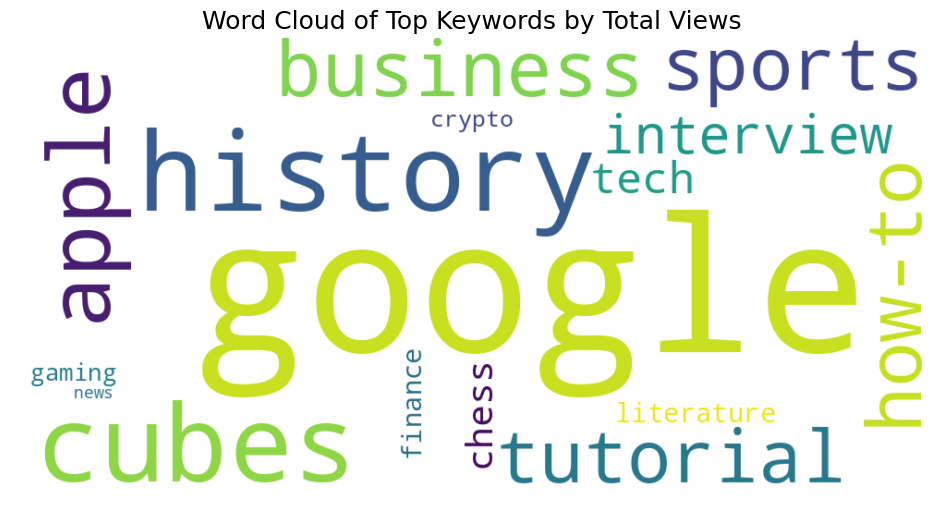

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Ensure we're working with unique video entries for accurate view counts per keyword
unique_videos_df = df_full.drop_duplicates(subset=['Video ID'])

# Group by Keyword and sum the views for each keyword
keyword_views = unique_videos_df.groupby('Keyword')['Views'].sum().sort_values(ascending=False)

# Prepare data for WordCloud, using views as frequencies
# We'll take the top 50 keywords by total views to ensure readability
wordcloud_data = {keyword: views for keyword, views in keyword_views.head(50).items()}

# Generate the word cloud
wordcloud = WordCloud(width=1000, height=500, background_color='white',
                      max_words=50, colormap='viridis').generate_from_frequencies(wordcloud_data)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Top Keywords by Total Views', fontsize=18)
plt.show()

#2 Top performing content (Videos tạo ra nhiều Views nhất & ROI nội dung)

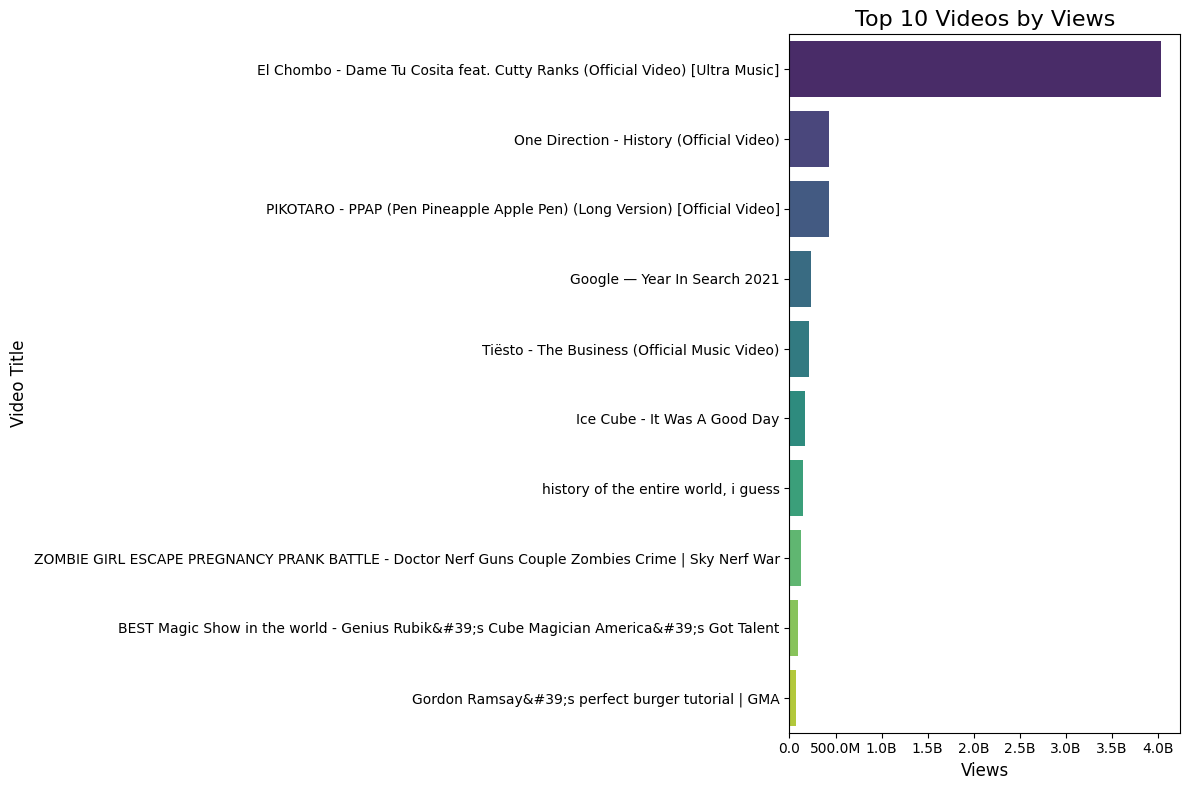

In [ ]:
import matplotlib.ticker as mticker

top_videos_by_views = df_full.sort_values(by='Views', ascending=False).drop_duplicates(subset=['Video ID']).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='Views', y='Title', data=top_videos_by_views, palette='viridis', hue='Title', legend=False)
plt.title('Top 10 Videos by Views', fontsize=16)
plt.xlabel('Views', fontsize=12)
plt.ylabel('Video Title', fontsize=12)

def millions_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    return str(x)

formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#3 Audience Engagement Quality — Engagement Rate


/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 3484 (\N{SINHALA LETTER ALPAPRAANA GAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 3546 (\N{SINHALA VOWEL SIGN DIGA KOMBUVA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 3508 (\N{SINHALA LETTER ALPAPRAANA PAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3115741856.py:28: UserWarning: Glyph 3490 (\N{SINHALA LETTER ALPAPRAANA JAYANNA}) missing from font(s) DejaVu Sans.
  

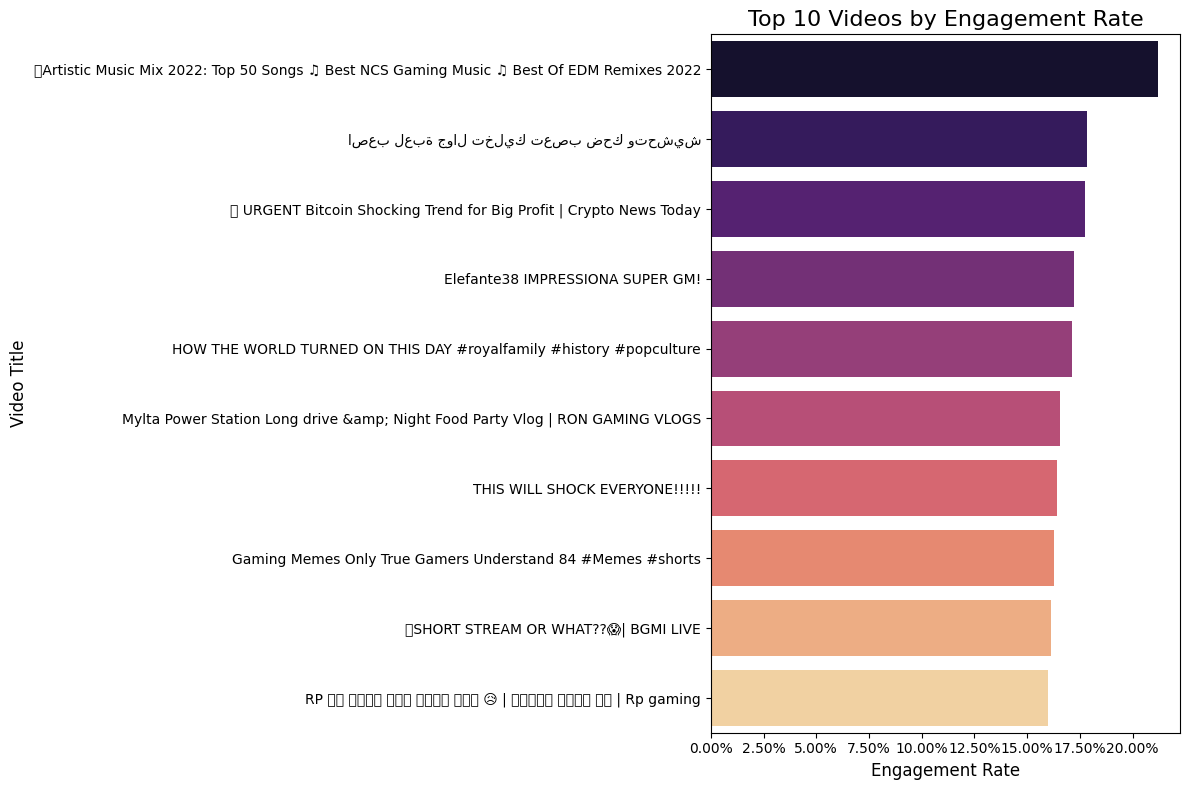

In [ ]:
import matplotlib.ticker as mticker

# Ensure engagement_rate is calculated and top_videos_by_engagement is available
# Engagement Rate = (Video_Likes + Video_Comments) / Views
# Handle potential division by zero by setting engagement_rate to 0 if Views is 0
if 'engagement_rate' not in df_full.columns:
    df_full['engagement_rate'] = df_full.apply(
        lambda row: (row['Video_Likes'] + row['Video_Comments']) / row['Views'] if row['Views'] > 0 else 0,
        axis=1
    )

# Get unique videos for plotting (each video should appear once)
df_videos_for_engagement_plot = df_full.drop_duplicates(subset=['Video ID'])

# Sort by engagement rate to find top videos
top_videos_by_engagement = df_videos_for_engagement_plot.sort_values(by='engagement_rate', ascending=False).head(10)

plt.figure(figsize=(12, 8))
sns.barplot(x='engagement_rate', y='Title', data=top_videos_by_engagement, palette='magma', hue='Title', legend=False)
plt.title('Top 10 Videos by Engagement Rate', fontsize=16)
plt.xlabel('Engagement Rate', fontsize=12)
plt.ylabel('Video Title', fontsize=12)

# Format x-axis to show percentage if desired, or just numbers
formatter = mticker.PercentFormatter(xmax=1, decimals=2) # Format as percentage
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#4 Group videos by Keyword. Calculate average Views and Engagement_Rate for each keyword.

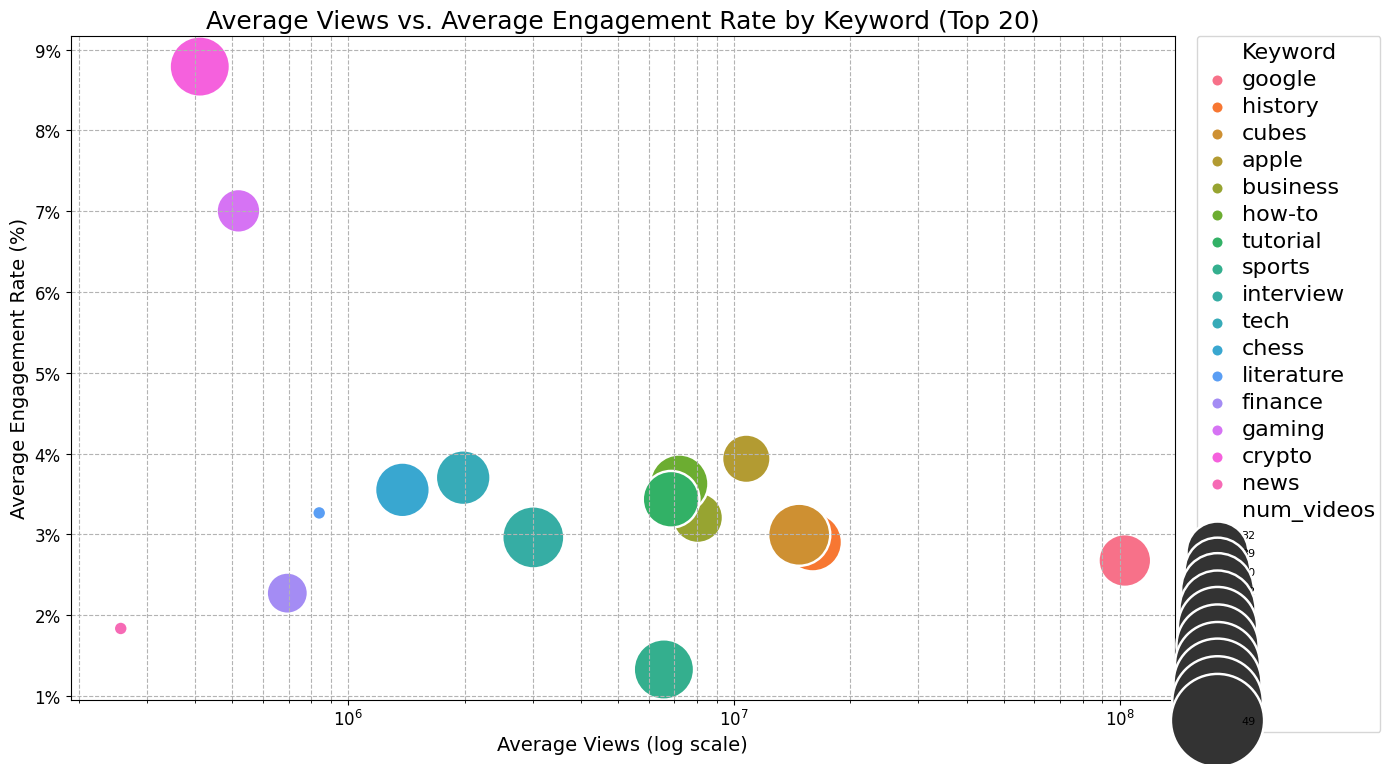

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Ensure engagement_rate is calculated on the full dataset first
if 'engagement_rate' not in df_full.columns:
    df_full['engagement_rate'] = df_full.apply(
        lambda row: (row['Video_Likes'] + row['Video_Comments']) / row['Views'] if row['Views'] > 0 else 0,
        axis=1
    )

# Get unique video entries to avoid double-counting for keyword analysis
unique_videos_df = df_full.drop_duplicates(subset=['Video ID'])

# Group by Keyword and calculate average views, average engagement rate, and count of videos
engagement_by_keyword = unique_videos_df.groupby('Keyword').agg(
    average_views=('Views', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean'),
    num_videos=('Video ID', 'count')
).reset_index()

# Sort by average views to focus on more prominent keywords
engagement_by_keyword_sorted = engagement_by_keyword.sort_values(by='average_views', ascending=False).head(20)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=engagement_by_keyword_sorted,
    x='average_views',
    y='average_engagement_rate',
    size='num_videos', # Size points by the number of videos for that keyword
    hue='Keyword', # Color points by keyword
    sizes=(100, 2000), # Adjust point sizes for better visualization
    legend='full' # Use 'full' to ensure all legend entries are shown
)

# Define formatter for Views axis with full unit names
def views_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f} Billion'
    elif x >= 1e6:
        return f'{x*1e-6:.1f} Million'
    elif x >= 1e3:
        return f'{x*1e-3:.1f} Thousand'
    return str(x)

# Apply formatters to axes
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(views_formatter))
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=0))

plt.xscale('log') # Use log scale for views if they span a very wide range

plt.title('Average Views vs. Average Engagement Rate by Keyword (Top 20)', fontsize=18) # Increased font size
plt.xlabel('Average Views (log scale)', fontsize=14) # Increased font size
plt.ylabel('Average Engagement Rate (%)', fontsize=14) # Increased font size
plt.xticks(fontsize=12) # Increased font size for ticks
plt.yticks(fontsize=12) # Increased font size for ticks
plt.grid(True, which="both", ls="--", c='0.7')

# Get the legend and set a larger font size and markerscale
legend = plt.gca().legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0., markerscale=1.5)
if legend:
    for text_obj in legend.get_texts():
        try:
            # If text can be converted to float, it's likely a size legend label
            float(text_obj.get_text())
            text_obj.set_fontsize(8) # Even smaller font size for size legend
        except ValueError:
            # Otherwise, it's a keyword label (hue legend)
            text_obj.set_fontsize(16) # Larger font size for keyword legend

plt.tight_layout()
plt.show()

### 4.1 Top 10 Keywords by Average Views

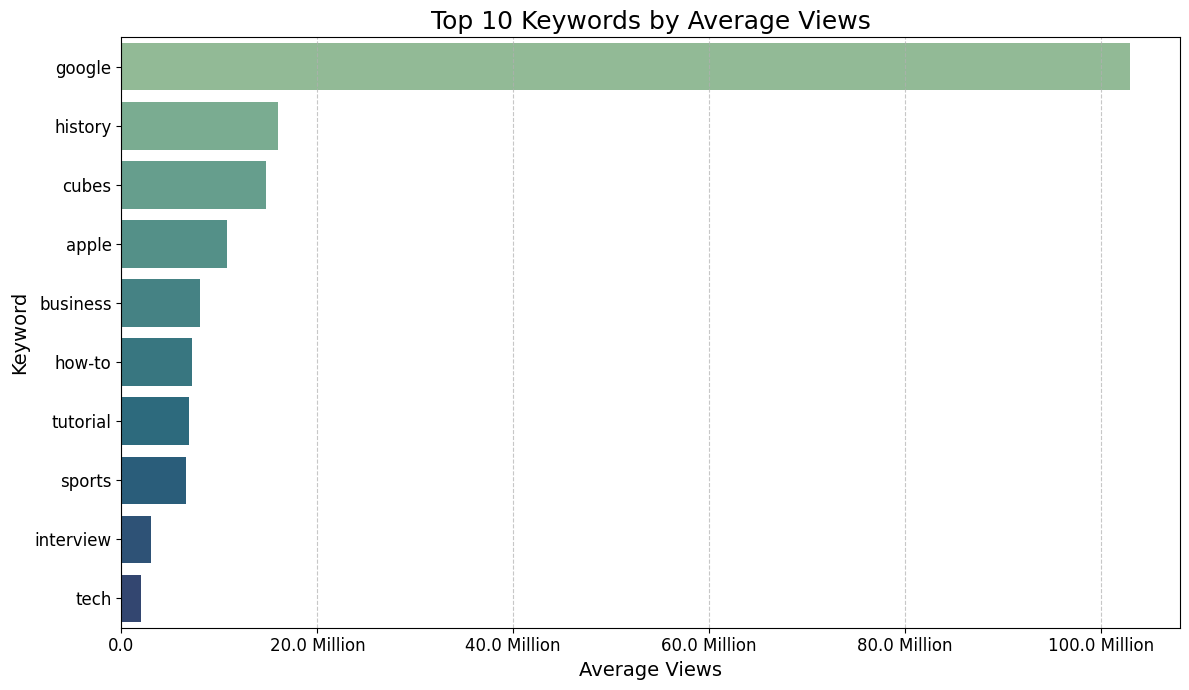

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Ensure engagement_rate is calculated on the full dataset first
if 'engagement_rate' not in df_full.columns:
    df_full['engagement_rate'] = df_full.apply(
        lambda row: (row['Video_Likes'] + row['Video_Comments']) / row['Views'] if row['Views'] > 0 else 0,
        axis=1
    )

# Get unique video entries to avoid double-counting for keyword analysis
unique_videos_df = df_full.drop_duplicates(subset=['Video ID'])

# Group by Keyword and calculate average views, average engagement rate
engagement_by_keyword = unique_videos_df.groupby('Keyword').agg(
    average_views=('Views', 'mean'),
    average_engagement_rate=('engagement_rate', 'mean')
).reset_index()

# Sort by average views to get the top keywords
top_keywords_by_avg_views = engagement_by_keyword.sort_values(by='average_views', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='average_views', y='Keyword', data=top_keywords_by_avg_views, palette='crest', hue='Keyword', legend=False)
plt.title('Top 10 Keywords by Average Views', fontsize=18)
plt.xlabel('Average Views', fontsize=14)
plt.ylabel('Keyword', fontsize=14)

# Define formatter for Views axis with full unit names
def views_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f} Billion'
    elif x >= 1e6:
        return f'{x*1e-6:.1f} Million'
    elif x >= 1e3:
        return f'{x*1e-3:.1f} Thousand'
    return str(x)

formatter = mticker.FuncFormatter(views_formatter)
plt.gca().xaxis.set_major_formatter(formatter)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### 4.2 Top 10 Keywords by Average Engagement Rate

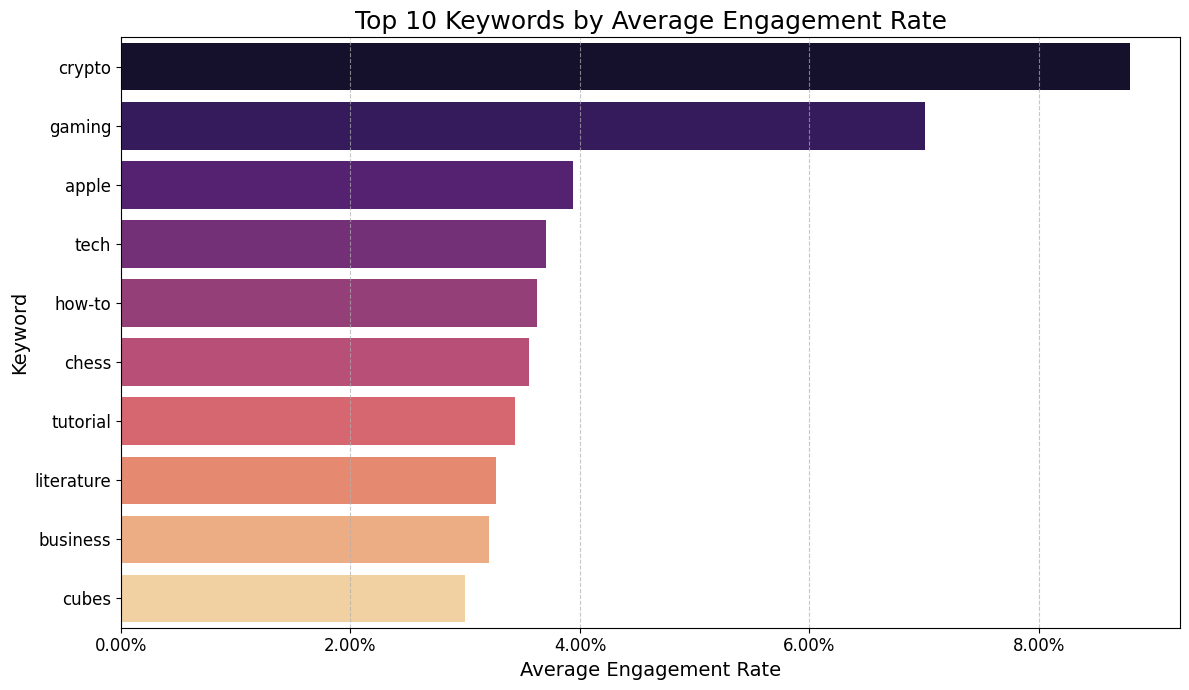

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# The `engagement_by_keyword` dataframe is already prepared from the previous cell.
# Sort by average engagement rate to get the top keywords
top_keywords_by_avg_engagement = engagement_by_keyword.sort_values(by='average_engagement_rate', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='average_engagement_rate', y='Keyword', data=top_keywords_by_avg_engagement, palette='magma', hue='Keyword', legend=False)
plt.title('Top 10 Keywords by Average Engagement Rate', fontsize=18)
plt.xlabel('Average Engagement Rate', fontsize=14)
plt.ylabel('Keyword', fontsize=14)

# Format x-axis to show percentage
formatter = mticker.PercentFormatter(xmax=1, decimals=2)
plt.gca().xaxis.set_major_formatter(formatter)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#5 Does my audience really love or hate me?
 (Sentiment & Engagement Analysis)

Many views are not necessarily good if they are all negative sentiments.

## 5.1 Relation Between Sentiment and Engagement_Rate

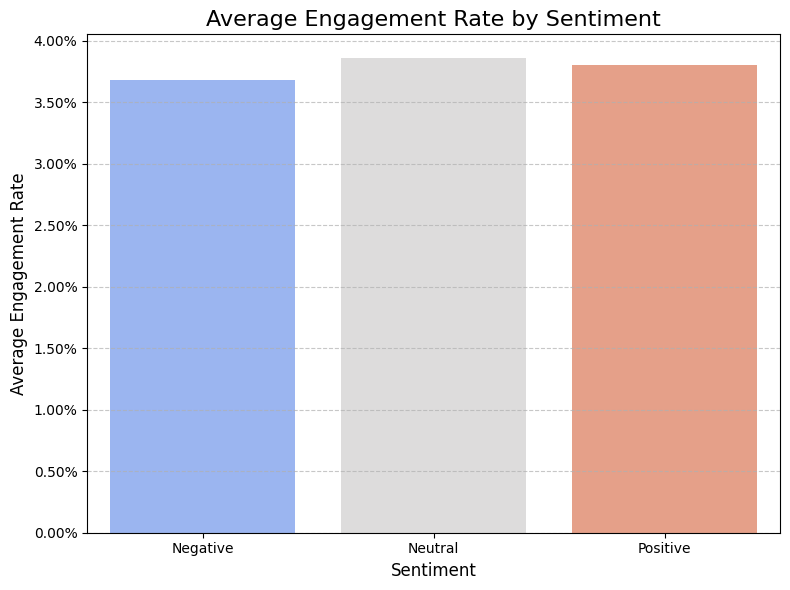

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map sentiment numerical values to meaningful labels
sentiment_mapping = {0.0: 'Negative', 1.0: 'Neutral', 2.0: 'Positive'}
df_full['Sentiment_Label'] = df_full['Sentiment'].map(sentiment_mapping)

# Calculate average engagement rate for each sentiment label
sentiment_engagement = df_full.groupby('Sentiment_Label')['engagement_rate'].mean().reindex(['Negative', 'Neutral', 'Positive'])

plt.figure(figsize=(8, 6))
sns.barplot(x=sentiment_engagement.index, y=sentiment_engagement.values, palette='coolwarm', hue=sentiment_engagement.index, legend=False)
plt.title('Average Engagement Rate by Sentiment', fontsize=16)
plt.xlabel('Sentiment', fontsize=12)
plt.ylabel('Average Engagement Rate', fontsize=12)
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##5.2 Videos with Sentiment_Label as "Negative" but high Views

Number of unique controversial videos found: 93


,Title,Views,Video_Likes,Video_Comments,Sentiment_Label
6177,PIKOTARO - PPAP (Pen Pineapple Apple Pen) (Lon...,425478119.0,4144389.0,294428.0,Negative
7734,"history of the entire world, i guess",147339243.0,5471653.0,395657.0,Negative
5271,BEST Magic Show in the world - Genius Rubik&#3...,94900199.0,954935.0,28908.0,Negative
4861,EVERY RUBIK&#39;S CUBE FROM 1x1 TO 19x19,58590655.0,2025653.0,8188.0,Negative
2793,How To Fix a Water Damaged Laptop,52061447.0,910553.0,81975.0,Negative
2722,Former FBI Agent Explains How to Read Body Lan...,44943014.0,1165120.0,40435.0,Negative
5093,Solving the huge Rubik&#39;s Cube 15X15 in rec...,39581966.0,636440.0,16875.0,Negative
5241,Learn How to Solve a Rubik&#39;s Cube in 10 Mi...,38289391.0,461154.0,47971.0,Negative
6927,Top New Comedy Video Amazing Funny Video 2021 ...,32300300.0,135952.0,2131.0,Negative
3112,How to Solve a Rubik&#39;s Cube | WIRED,29905105.0,339758.0,32718.0,Negative


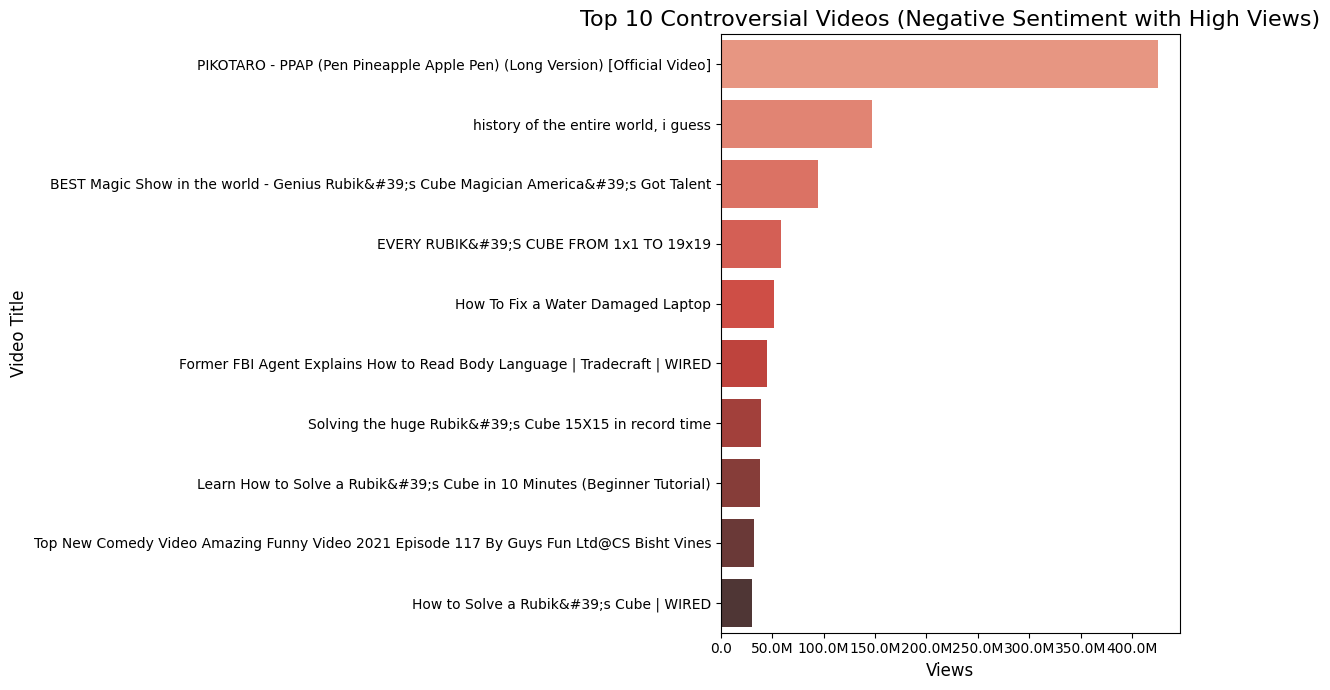

In [ ]:
import numpy as np

# Ensure 'Sentiment_Label' exists (from previous cell)
if 'Sentiment_Label' not in df_full.columns:
    sentiment_mapping = {0.0: 'Negative', 1.0: 'Neutral', 2.0: 'Positive'}
    df_full['Sentiment_Label'] = df_full['Sentiment'].map(sentiment_mapping)

# Define 'high views' as videos with views above the 75th percentile
high_views_threshold = df_full['Views'].quantile(0.75)

# Filter for videos with Negative Sentiment and high views
controversial_videos = df_full[
    (df_full['Sentiment_Label'] == 'Negative') &
    (df_full['Views'] > high_views_threshold)
]

# Drop duplicates based on 'Video ID' to ensure each video is counted once
controversial_videos = controversial_videos.drop_duplicates(subset=['Video ID'])

# Sort by Views in descending order and select the top 10
top_controversial_videos = controversial_videos.sort_values(by='Views', ascending=False).head(10)

print(f"Number of unique controversial videos found: {len(controversial_videos)}")

# Display relevant columns
display(top_controversial_videos[['Title', 'Views', 'Video_Likes', 'Video_Comments', 'Sentiment_Label']])


plt.figure(figsize=(12, 7))
sns.barplot(x='Views', y='Title', data=top_controversial_videos, palette='Reds_d', hue='Title', legend=False)
plt.title('Top 10 Controversial Videos (Negative Sentiment with High Views)', fontsize=16)
plt.xlabel('Views', fontsize=12)
plt.ylabel('Video Title', fontsize=12)

# Format x-axis to show millions/billions
formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

##5.3 Sentiment_Labelare "Positive" but Views low

Number of unique underrated videos found: 177


,Title,Views,Video_Likes,Video_Comments,Sentiment_Label
2551,The NFL Experience with Kai Nacua and Tyler Al...,867.0,15.0,1.0,Positive
4069,Student loan forgiveness a &#39;lose-lose&#39;...,1485.0,13.0,21.0,Positive
4589,BITBOY CRYPTO SUES @Atozy CRAZY CRYPTO STORY,1599.0,105.0,51.0,Positive
4579,Raoul Pal Update: Time Is Running Out &amp; Cr...,1616.0,66.0,105.0,Positive
6083,Was bringt das Apple-September-2022-Event - 4K...,1954.0,184.0,47.0,Positive
4366,ATOM COSMOS PREND SON ENVOL 🔥 DOSSIER MAJEUR D...,2201.0,230.0,95.0,Positive
1788,RP ගේ පේජ් එකට මොකද උනේ 😥 | අලුත් පේජ් එක | Rp...,2386.0,358.0,23.0,Positive
4663,"INVESTOR BIG SHORT INI MENJUAL 98% ASETNYA, AP...",2546.0,92.0,55.0,Positive
4293,"Finance influencer talks social media, retail ...",2548.0,57.0,13.0,Positive
7594,Mossbag Interview: Kickstarter for New Game - ...,2587.0,242.0,28.0,Positive


/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 3484 (\N{SINHALA LETTER ALPAPRAANA GAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 3546 (\N{SINHALA VOWEL SIGN DIGA KOMBUVA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 3508 (\N{SINHALA LETTER ALPAPRAANA PAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-3945321531.py:38: UserWarning: Glyph 3490 (\N{SINHALA LETTER ALPAPRAANA JAYANNA}) missing from font(s) DejaVu Sans.
  plt.tig

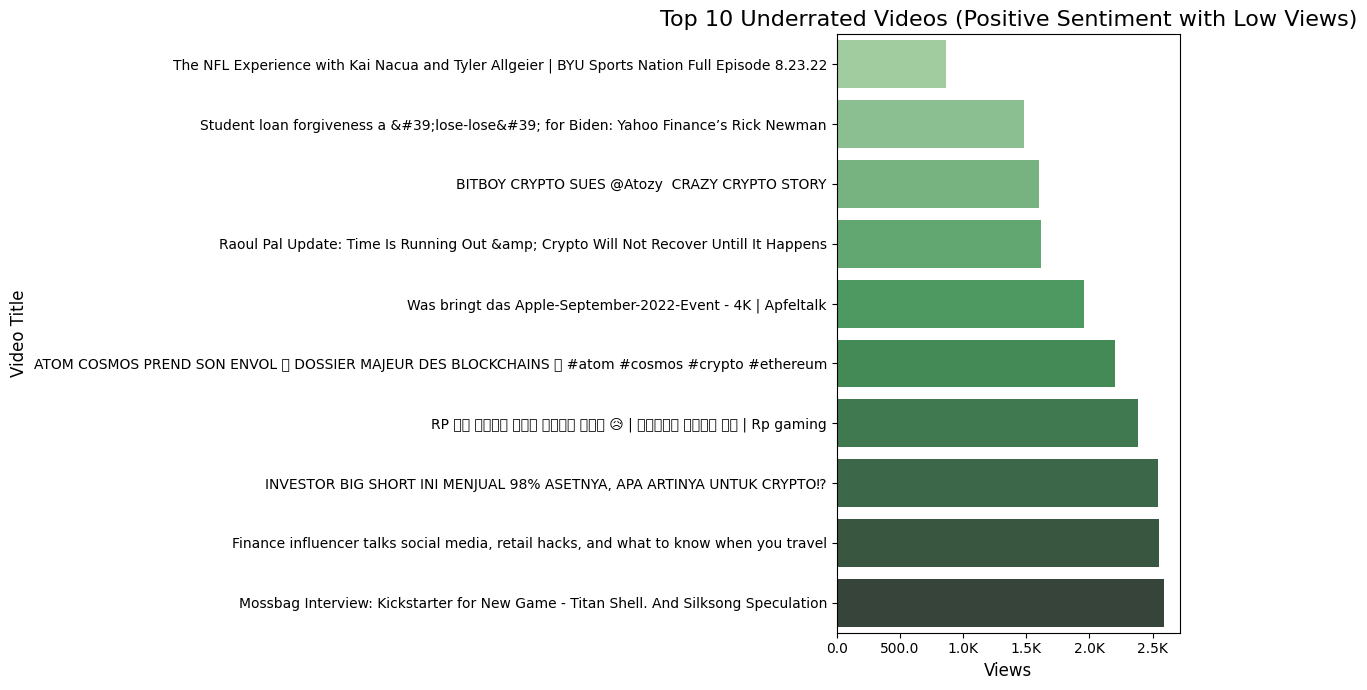

In [ ]:
import numpy as np

# Ensure 'Sentiment_Label' exists
if 'Sentiment_Label' not in df_full.columns:
    sentiment_mapping = {0.0: 'Negative', 1.0: 'Neutral', 2.0: 'Positive'}
    df_full['Sentiment_Label'] = df_full['Sentiment'].map(sentiment_mapping)

# Define 'low views' as videos with views below the 25th percentile
low_views_threshold = df_full['Views'].quantile(0.25)

# Filter for videos with Positive Sentiment and low views
underrated_videos = df_full[
    (df_full['Sentiment_Label'] == 'Positive') &
    (df_full['Views'] < low_views_threshold)
]

# Drop duplicates based on 'Video ID' to ensure each video is counted once
underrated_videos = underrated_videos.drop_duplicates(subset=['Video ID'])

# Sort by Views in ascending order and select the top 10 (lowest views among positive sentiment)
top_underrated_videos = underrated_videos.sort_values(by='Views', ascending=True).head(10)

print(f"Number of unique underrated videos found: {len(underrated_videos)}")

# Display relevant columns
display(top_underrated_videos[['Title', 'Views', 'Video_Likes', 'Video_Comments', 'Sentiment_Label']])

plt.figure(figsize=(12, 7))
sns.barplot(x='Views', y='Title', data=top_underrated_videos, palette='Greens_d', hue='Title', legend=False)
plt.title('Top 10 Underrated Videos (Positive Sentiment with Low Views)', fontsize=16)
plt.xlabel('Views', fontsize=12)
plt.ylabel('Video Title', fontsize=12)

# Format x-axis to show thousands if applicable
formatter = mticker.FuncFormatter(millions_formatter) # Reusing the previously defined formatter
plt.gca().xaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()

#6 What is the best time to post a video? (Temporal Analysis)

## 6.1 Analyze average views by month

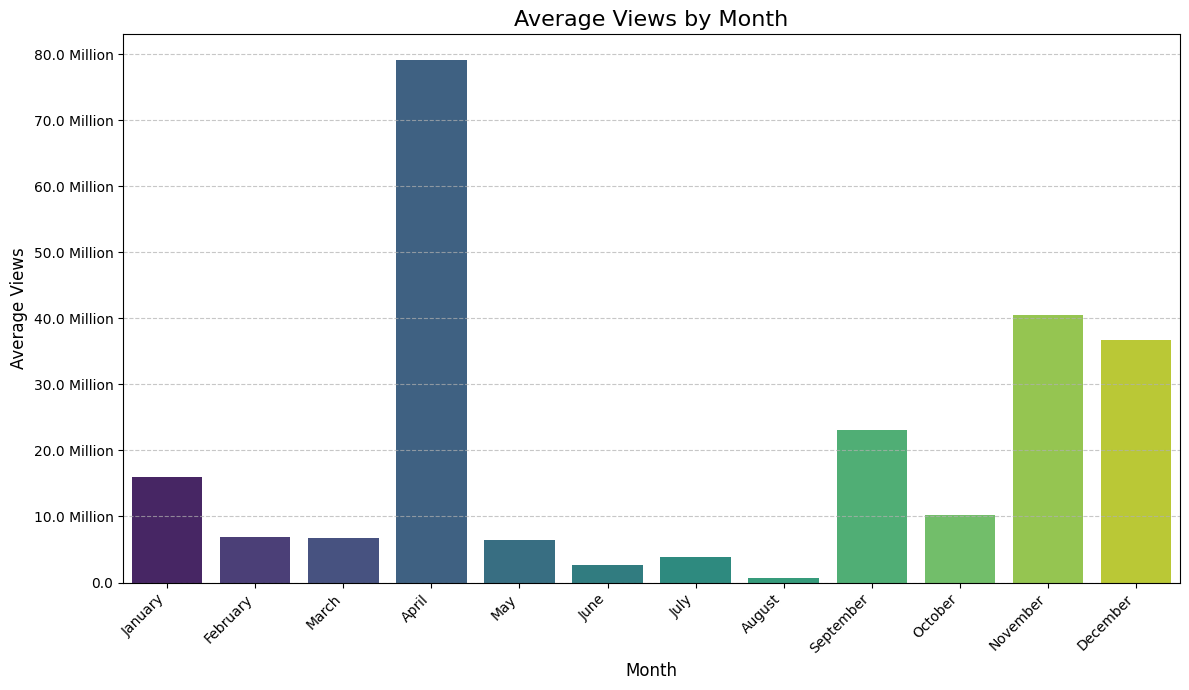

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Create a DataFrame `monthly_views` by grouping `df_full` by 'Month_Name' and calculating the mean of 'Views'.
monthly_views = df_full.groupby('Month_Name')['Views'].mean().reset_index()

# Define the correct order for the months (e.g., January to December) in a list called `month_order`.
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

# Reindex `monthly_views` using `month_order` to ensure the bar chart displays months in chronological sequence.
monthly_views['Month_Name'] = pd.Categorical(monthly_views['Month_Name'], categories=month_order, ordered=True)
monthly_views = monthly_views.sort_values('Month_Name')

# Create a bar plot using `seaborn.barplot` with 'Month_Name' on the x-axis and 'Views' on the y-axis.
plt.figure(figsize=(12, 7))
sns.barplot(x='Month_Name', y='Views', data=monthly_views, palette='viridis', hue='Month_Name', legend=False)

# Set the title of the plot to 'Average Views by Month'.
plt.title('Average Views by Month', fontsize=16)

# Label the x-axis as 'Month' and the y-axis as 'Average Views'.
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Views', fontsize=12)

# Format the y-axis labels to display views in a readable format.
formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Display the plot.
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6.2 Analyze average views by day in week.

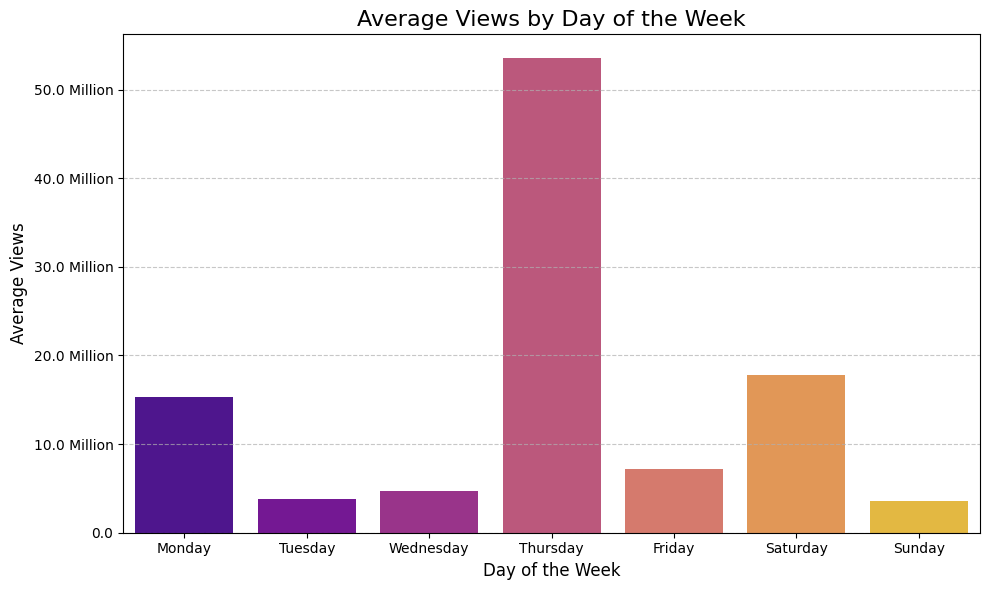

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Create a DataFrame `daily_views` by grouping `df_full` by 'Day_Name' and calculating the mean of 'Views'.
daily_views = df_full.groupby('Day_Name')['Views'].mean().reset_index()

# Define the correct order for the days of the week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# Reindex `daily_views` using `day_order` to ensure the bar chart displays days in chronological sequence.
daily_views['Day_Name'] = pd.Categorical(daily_views['Day_Name'], categories=day_order, ordered=True)
daily_views = daily_views.sort_values('Day_Name')

# Create a bar plot using `seaborn.barplot` with 'Day_Name' on the x-axis and 'Views' on the y-axis.
plt.figure(figsize=(10, 6))
sns.barplot(x='Day_Name', y='Views', data=daily_views, palette='plasma', hue='Day_Name', legend=False)

# Set the title of the plot to 'Average Views by Day of the Week'.
plt.title('Average Views by Day of the Week', fontsize=16)

# Label the x-axis as 'Day of the Week' and the y-axis as 'Average Views'.
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Average Views', fontsize=12)

# Format the y-axis labels to display views in a readable format.
formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Display the plot.
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6.3 Analyze seasonality of selected keywords "Tech"



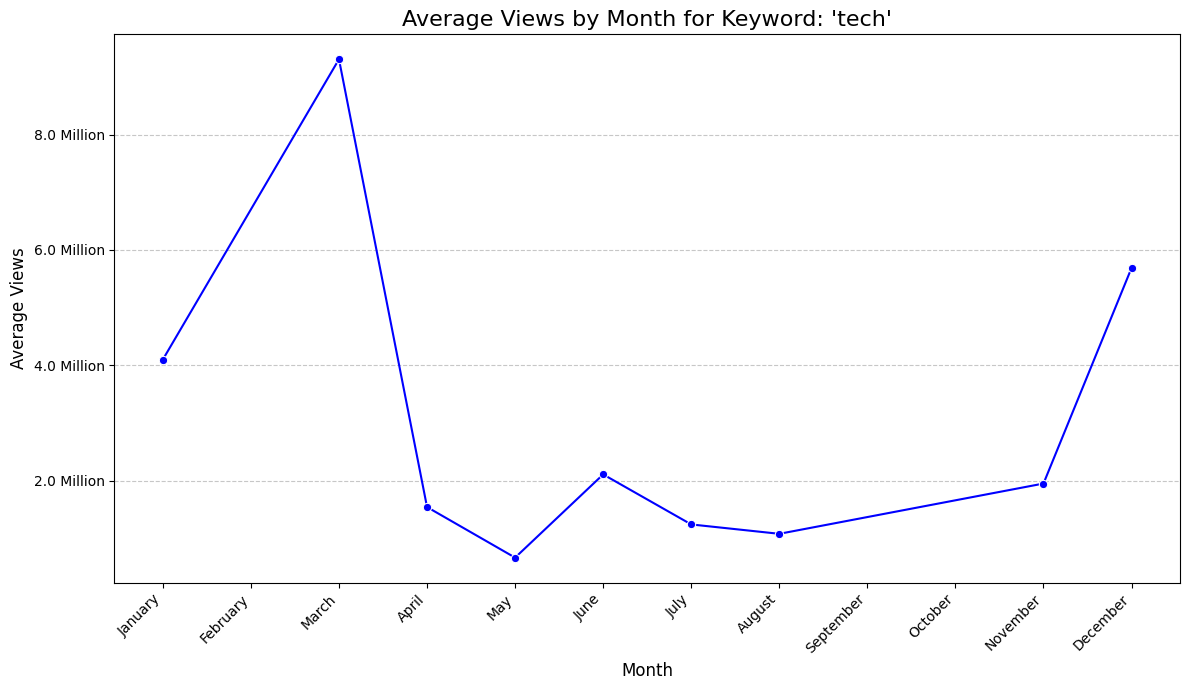

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Select a keyword for seasonality analysis
selected_keyword = 'tech'

# Filter the DataFrame for the selected keyword
keyword_df = df_full[df_full['Keyword'] == selected_keyword].copy()

# Get unique video entries to avoid double-counting views for the same video
unique_keyword_videos = keyword_df.drop_duplicates(subset=['Video ID'])

# Calculate average views by month for the selected keyword
monthly_keyword_views = unique_keyword_videos.groupby('Month_Name')['Views'].mean().reset_index()

# Define the correct order for the months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

# Reindex monthly_keyword_views to ensure months are in chronological order
monthly_keyword_views['Month_Name'] = pd.Categorical(monthly_keyword_views['Month_Name'], categories=month_order, ordered=True)
monthly_keyword_views = monthly_keyword_views.sort_values('Month_Name')

# Create a line plot to visualize seasonality
plt.figure(figsize=(12, 7))
sns.lineplot(x='Month_Name', y='Views', data=monthly_keyword_views, marker='o', color='blue')

# Set the title of the plot
plt.title(f'Average Views by Month for Keyword: \'{selected_keyword}\'', fontsize=16)

# Label the x-axis and y-axis
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Views', fontsize=12)

# Format the y-axis labels to display views in a readable format.
formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 6.4 Analyze seasonality of selected keywords "Gaming"



**Reasoning**:
To analyze the seasonality of the 'gaming' keyword, I will follow the same steps as the previous keyword analysis: filter the DataFrame, group by month, order the months, and then create a line plot to visualize the average views per month.



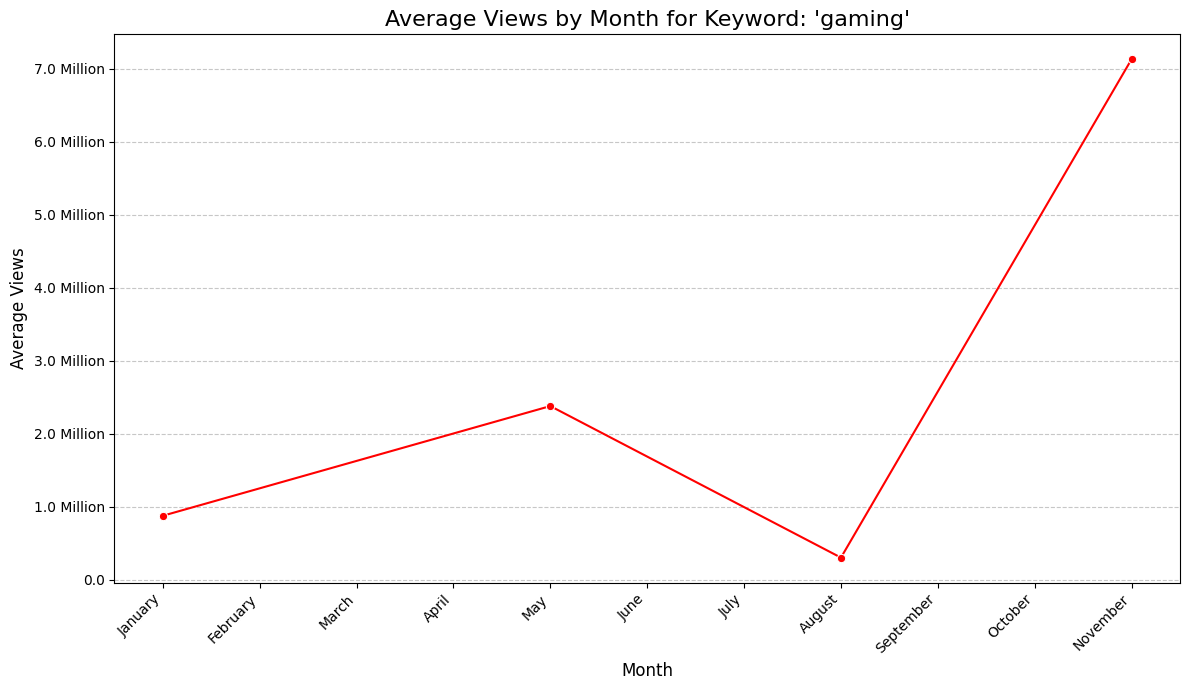

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# Select a new keyword for seasonality analysis
selected_keyword = 'gaming'

# Filter the DataFrame for the selected keyword
keyword_df = df_full[df_full['Keyword'] == selected_keyword].copy()

# Get unique video entries to avoid double-counting views for the same video
unique_keyword_videos = keyword_df.drop_duplicates(subset=['Video ID'])

# Calculate average views by month for the selected keyword
monthly_keyword_views = unique_keyword_videos.groupby('Month_Name')['Views'].mean().reset_index()

# Define the correct order for the months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July',
               'August', 'September', 'October', 'November', 'December']

# Reindex monthly_keyword_views to ensure months are in chronological order
monthly_keyword_views['Month_Name'] = pd.Categorical(monthly_keyword_views['Month_Name'], categories=month_order, ordered=True)
monthly_keyword_views = monthly_keyword_views.sort_values('Month_Name')

# Create a line plot to visualize seasonality
plt.figure(figsize=(12, 7))
sns.lineplot(x='Month_Name', y='Views', data=monthly_keyword_views, marker='o', color='red')

# Set the title of the plot
plt.title(f'Average Views by Month for Keyword: \'{selected_keyword}\'', fontsize=16)

# Label the x-axis and y-axis
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Views', fontsize=12)

# Format the y-axis labels to display views in a readable format.
formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#7 Analyze top comments by Comment_Likes


In [ ]:
top_comments = df_full.sort_values(by='Comment_Likes', ascending=False).head(10)
display(top_comments[['Video ID', 'Title', 'Comment', 'Comment_Likes']])

KeyError: 'Comment_Likes'

#Summary


##1 Performance Matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

# 1. Ensure the 'engagement_rate' column is calculated
# Engagement Rate = (Video_Likes + Video_Comments) / Views
# Handle potential division by zero by setting engagement_rate to 0 if Views is 0

# Create a copy to avoid SettingWithCopyWarning if df_full was previously a slice
df_full_copy = df_full.copy()

if 'engagement_rate' not in df_full_copy.columns:
    df_full_copy['engagement_rate'] = df_full_copy.apply(
        lambda row: (row['Video_Likes'] + row['Video_Comments']) / row['Views'] if row['Views'] > 0 else 0,
        axis=1
    )

# 2. Create a scatter plot using unique video entries
unique_videos_performance = df_full_copy.drop_duplicates(subset=['Video ID'])

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=unique_videos_performance,
    x='engagement_rate',
    y='Views',
    hue='Keyword', # Use Keyword for color to add more insight
    size='Video_Likes', # Use Video_Likes for size to represent another dimension
    sizes=(50, 1000), # Adjust size range for better visualization
    alpha=0.7
)

# 3. Set the plot title
plt.title('Engagement Rate vs. Views Performance Matrix', fontsize=18)

# 4. Label the x-axis and y-axis
plt.xlabel('Engagement Rate', fontsize=14)
plt.ylabel('Views', fontsize=14)

# 5. Format the x-axis to display engagement rates as percentages
plt.gca().xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=2))

# 6. Format the y-axis to display views in a readable format (e.g., millions, billions)
def millions_formatter(x, pos):
    if x >= 1e9:
        return f'{x*1e-9:.1f}B'
    elif x >= 1e6:
        return f'{x*1e-6:.1f}M'
    elif x >= 1e3:
        return f'{x*1e-3:.1f}K'
    return str(x)

formatter = mticker.FuncFormatter(millions_formatter)
plt.gca().yaxis.set_major_formatter(formatter)

# Add x-axis to log scale if views span a very wide range for better visualization
plt.yscale('log')

# 7. Add a grid to the plot for better readability
plt.grid(True, which="both", ls="--", c='0.7')

# Place legend outside the plot to avoid overlapping
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Adjust layout
plt.tight_layout()

# 8. Display the plot
plt.show()

##2 Sentiment Word Cloud

In [ ]:
from wordcloud import WordCloud, STOPWORDS

# Filter comments by sentiment
positive_comments = df_full[df_full['Sentiment_Label'] == 'Positive']['Comment']
negative_comments = df_full[df_full['Sentiment_Label'] == 'Negative']['Comment']

# Concatenate all positive comments into a single string
all_positive_comments = ' '.join(positive_comments.astype(str))

# Concatenate all negative comments into a single string
all_negative_comments = ' '.join(negative_comments.astype(str))

print(f"Number of positive comments collected: {len(positive_comments)}")
print(f"Number of negative comments collected: {len(negative_comments)}")

In [ ]:
wordcloud_positive = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(all_positive_comments)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Comments', fontsize=18)
plt.show()

In [ ]:
wordcloud_negative = WordCloud(width=800, height=400, background_color='white', stopwords=STOPWORDS).generate(all_negative_comments)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Comments', fontsize=18)
plt.show()